In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Walk up from cwd until we find pyproject.toml (Jupyter sets cwd to the notebook
# folder, so the repo root is not cwd).
project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import analysis
from src import label_switching as ls

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 5)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Load Posterior Draws ──────────
# This notebook lives in <run>/ ; all artifacts live in <run>/results/.

def _resolve_run_dir():
    # VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        return pathlib.Path(nb).resolve().parent
    return pathlib.Path.cwd()

RUN_DIR     = _resolve_run_dir()
RESULTS_DIR = RUN_DIR / "results"
meta_path   = RESULTS_DIR / "meta.json"

if not meta_path.exists():
    raise FileNotFoundError(
        f"meta.json not found in:\n  {RESULTS_DIR}\n\n"
        f"This notebook must live in a run folder with artifacts in a results/ subfolder.\n"
        f"If you are in VS Code and this fails, set\n"
        f"  \"jupyter.notebookFileRoot\": \"${{fileDirname}}\"\n"
        f"so the working directory is the notebook's own folder, then restart the kernel."
    )

with open(meta_path) as f:
    meta = json.load(f)

SCENARIO_NAME = meta["scenario"]
K_MODEL       = int(meta["k_model"])
K_TRUE        = int(meta["k_true"])
SAMPLER       = meta["sampler"]
CHAINS        = int(meta["chains"])

with open(RESULTS_DIR / "posterior_raw.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(f"Run folder : {RUN_DIR}")
print(f"Scenario   : {SCENARIO_NAME}   sampler: {SAMPLER}   chains: {CHAINS}")
print(f"K_MODEL    : {K_MODEL}   K_TRUE : {K_TRUE}")
print("\nPosterior arrays:")
for key, val in posterior_samples.items():
    print(f"   {key:<28} {np.asarray(val).shape}")

Run folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\2_chains\2_comp\HMC\2comp_equal_K5_seed42
Scenario   : 2comp_equal   sampler: hmc   chains: 2
K_MODEL    : 5   K_TRUE : 2

Posterior arrays:
   Delta                        (2, 10000, 2, 4)
   beta_i                       (2, 10000, 300, 4)
   mu_k                         (2, 10000, 5, 4)
   pvec_latent                  (2, 10000, 4)
   sigma_inv_chol_k_latent      (2, 10000, 5, 10)


In [3]:
# ── Cell 3 : Ground Truth & Demographics ──────────
# Z is needed to reconstruct allocations via the household-specific mean
# mu_k + Z_i @ Delta (Rossi Eq. 5.5.19).
data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"
with open(data_path) as f:
    raw_data = json.load(f)

P       = int(raw_data["n_params"])
D       = int(raw_data.get("n_demos", 0))
n_units = int(raw_data["n_units"])

def _arr(key):
    return np.array(raw_data[key]) if raw_data.get(key) is not None else None

t_mu   = _arr("TRUE_MU_K")     # (K_TRUE, P)
t_pvec = _arr("TRUE_PVEC")     # (K_TRUE,)
Z      = _arr("Z")             # (N, D) demographics

param_names = raw_data.get("param_names") or [f"Param_{i}" for i in range(P)]

print(f"Ground truth from {data_path.name}  (P={P}, D={D}, N={n_units})")
if t_pvec is not None:
    print(f"TRUE_PVEC : {t_pvec.round(4)}")

Ground truth from 2comp_equal.json  (P=4, D=2, N=300)
TRUE_PVEC : [0.5 0.5]


In [4]:
# ── Cell 4 : Invariant-Convergence Gate ──────────
# Relabeling removes PERMUTATION ambiguity only - it cannot fix genuine
# multimodality. So FIRST assess convergence on the label-INVARIANT functionals
# (mixture mean E[u], sorted pvec, tr Cov[u]). A high sorted-pvec R-hat means the
# weight posterior is genuinely multimodal (the established K=5 finding), NOT a
# label artifact, and no relabeling can fix that.
gate = analysis.invariant_convergence_summary(posterior_samples, include_cov=True)
display(gate.round(4))

,rhat,ess
quantity,,
E[u]_0,1.0193,65.6326
E[u]_1,1.0400,37.0460
E[u]_2,1.0183,171.2126
E[u]_3,1.0195,84.5331
pvec_sorted_0,1.9062,6.1194
pvec_sorted_1,2.1081,6.2036
pvec_sorted_2,1.8306,25.2812
pvec_sorted_3,1.8411,61.0142
pvec_sorted_4,1.9821,62.2281


In [5]:
# ── Cell 5 : ECR.iterative.1 Relabeling ──────────
# Pivot-free ECR.iterative.1 (Papastamoulis & Iliopoulos 2010; the label.switching
# R package). Allocations are reconstructed from mu_k + Z@Delta, Sigma_k, pvec and
# beta_i (Liesel marginalizes them), so the SAME method serves NUTS / HMC / bayesm.
relabeled, report = ls.relabel_run(posterior_samples, K=K_MODEL, Z=Z, K_true=K_TRUE)
verdict = ls.classify_outcome(report, gate)

print(f"ECR converged   : {report['converged']}  (in {report['n_iter']} sweeps)")
print(f"switching rate  : {report['switching_rate']:.3f}  (fraction of draws relabeled)")
print(f"invariant Rhats : pvec_sorted={verdict['invariant_pvec_sorted_rhat']:.3f}  "
      f"E[u]={verdict['invariant_Eu_rhat']:.3f}  (gate_passed={verdict['gate_passed']})")
print(f"\nVERDICT : {verdict['verdict']}")

ECR converged   : True  (in 5 sweeps)
switching rate  : 0.776  (fraction of draws relabeled)
invariant Rhats : pvec_sorted=2.108  E[u]=1.040  (gate_passed=True)

VERDICT : MULTIMODAL (genuine - sorting removed labels, so not a label artifact; ECR aligns within-mode only)


Mean pvec per slot (before = label-switched -> smeared; after = ordered):


,mean_pvec_before,mean_pvec_after
slot 0,0.240,0.510
slot 1,0.003,0.477
slot 2,0.007,0.007
slot 3,0.510,0.004
slot 4,0.240,0.003


Per-component R-hat / ESS - BEFORE:


stage   rhat       ess
slot live  quantity                         
3    True  pvec      before  1.983    22.435
           mu[0]     before  1.022    64.948
           mu[1]     before  1.035    99.713
           mu[2]     before  1.042   107.321
           mu[3]     before  1.016   212.623
4    True  pvec      before  2.231     2.846
           mu[0]     before  1.760   290.311
           mu[1]     before  1.767   231.083
           mu[2]     before  1.759   790.710
           mu[3]     before  1.715     7.726
0    False pvec      before  2.118     2.606
           mu[0]     before  1.745    10.584
           mu[1]     before  1.780     9.921
           mu[2]     before  1.788   141.008
           mu[3]     before  1.747     4.952
2    False pvec      before  1.911     8.978
           mu[0]     before  1.040    38.870
           mu[1]     before  1.167     9.359
           mu[2]     before  1.007   292.144
           mu[3]     before  1.018   171.290
1    False pvec      before  2.039    14.582
           mu[0]     before  1.013   766.084
           mu[1]     before  1.003   185.988
           mu[2]     before  1.025  1988.359
           mu[3]     before  1.013   478.896

Per-component R-hat / ESS - AFTER:


stage   rhat      ess
slot live  quantity                       
0    True  pvec      after  1.983   22.435
           mu[0]     after  1.022   64.948
           mu[1]     after  1.035   99.713
           mu[2]     after  1.042  107.321
           mu[3]     after  1.016  212.623
1    True  pvec      after  1.934   44.272
           mu[0]     after  1.005   62.501
           mu[1]     after  1.012   70.114
           mu[2]     after  1.012  104.456
           mu[3]     after  1.013   39.934
2    False pvec      after  1.618   10.590
           mu[0]     after  1.033   42.694
           mu[1]     after  1.069   24.563
           mu[2]     after  1.022  226.795
           mu[3]     after  1.013  149.028
3    False pvec      after  1.519    4.299
           mu[0]     after  1.033  844.456
           mu[1]     after  1.035   66.917
           mu[2]     after  1.047  901.100
           mu[3]     after  1.018  175.602
4    False pvec      after  1.621   30.454
           mu[0]     after  1.016  336.715
           mu[1]     after  1.010  383.687
           mu[2]     after  1.009  336.773
           mu[3]     after  1.002  639.428

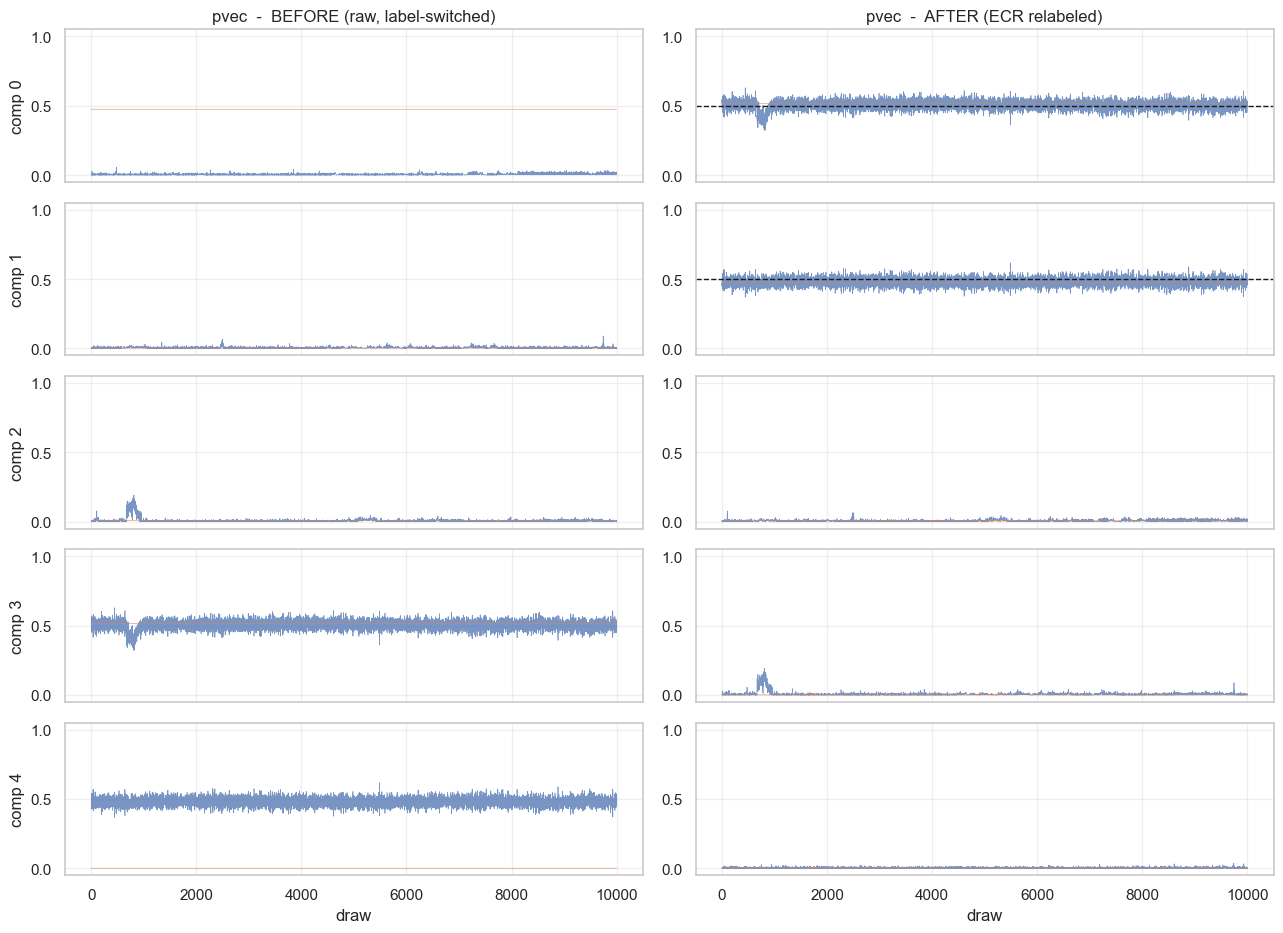

In [6]:
# ── Cell 6 : pvec - Full Before / After (ALL components) ──────────
pvec_before = np.asarray(analysis._recover_pvec(posterior_samples))   # (C,S,K)
pvec_after  = np.asarray(relabeled["pvec"])                           # (C,S,K)

# Mean weight per component, before vs after (all K slots).
mb = pvec_before.reshape(-1, K_MODEL).mean(0)
ma = pvec_after.reshape(-1, K_MODEL).mean(0)
print("Mean pvec per slot (before = label-switched -> smeared; after = ordered):")
display(pd.DataFrame({"mean_pvec_before": mb.round(3), "mean_pvec_after": ma.round(3)},
                     index=[f"slot {k}" for k in range(K_MODEL)]))

# R-hat / ESS for EVERY component (live = K_TRUE heaviest, flagged). For purely
# within-chain switching R-hat can already be ~1 - then ESS recovery is the signal.
print("Per-component R-hat / ESS - BEFORE:")
display(ls.component_convergence_table(posterior_samples, K_MODEL, K_TRUE,
        label="before", all_slots=True).set_index(["slot", "live", "quantity"]).round(3))
print("Per-component R-hat / ESS - AFTER:")
display(ls.component_convergence_table(relabeled, K_MODEL, K_TRUE,
        label="after", all_slots=True).set_index(["slot", "live", "quantity"]).round(3))

# Trace grid for EVERY pvec component, raw (before) vs relabeled (after).
# y-axis fixed to (-0.05, 1.05) to match the analysis notebook's pvec traces.
ls.plot_before_after_traces(pvec_before, pvec_after, K_MODEL, title="pvec",
                            true_vals=t_pvec, K_true=K_TRUE, ylim=(-0.05, 1.05))

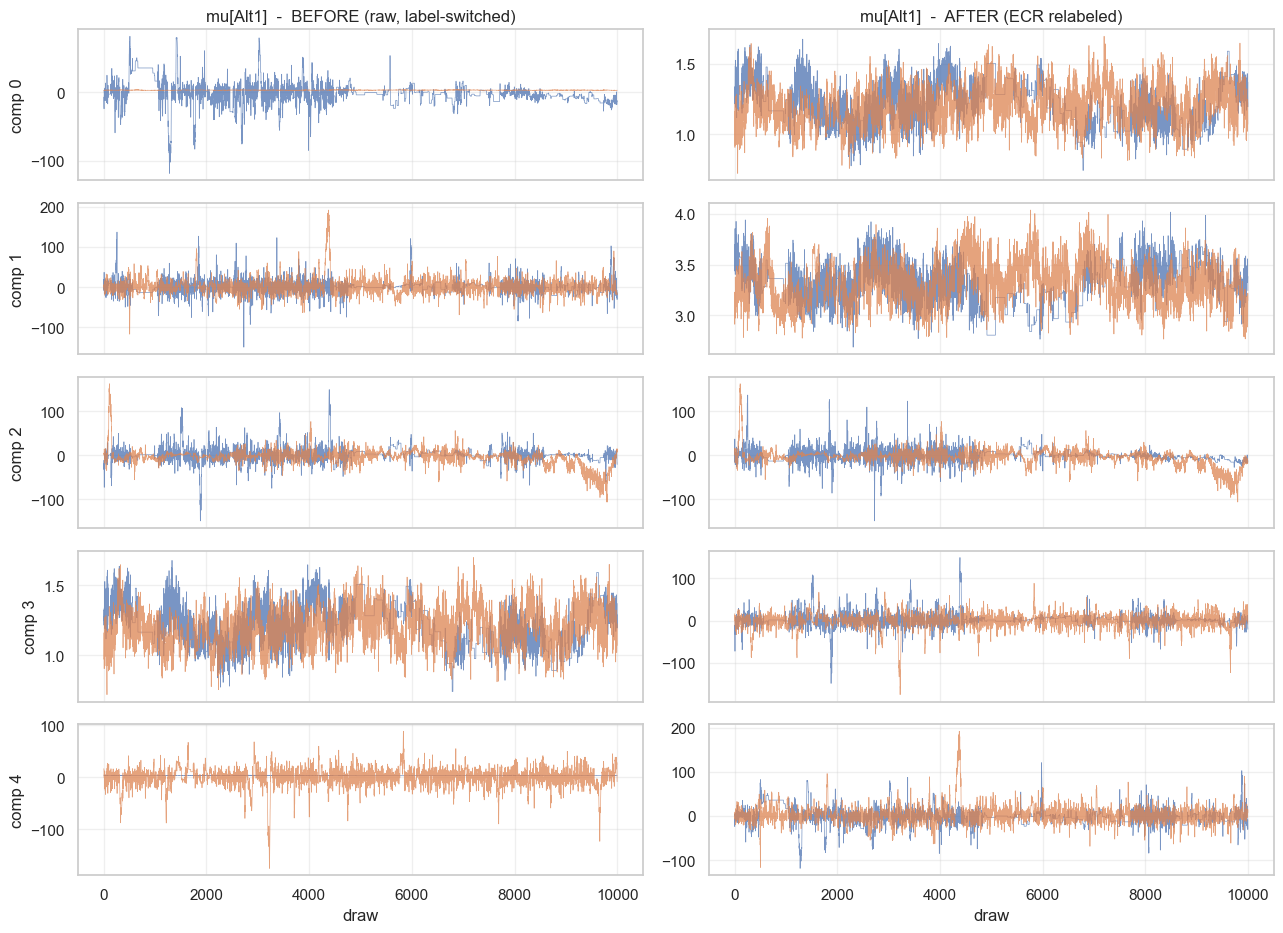

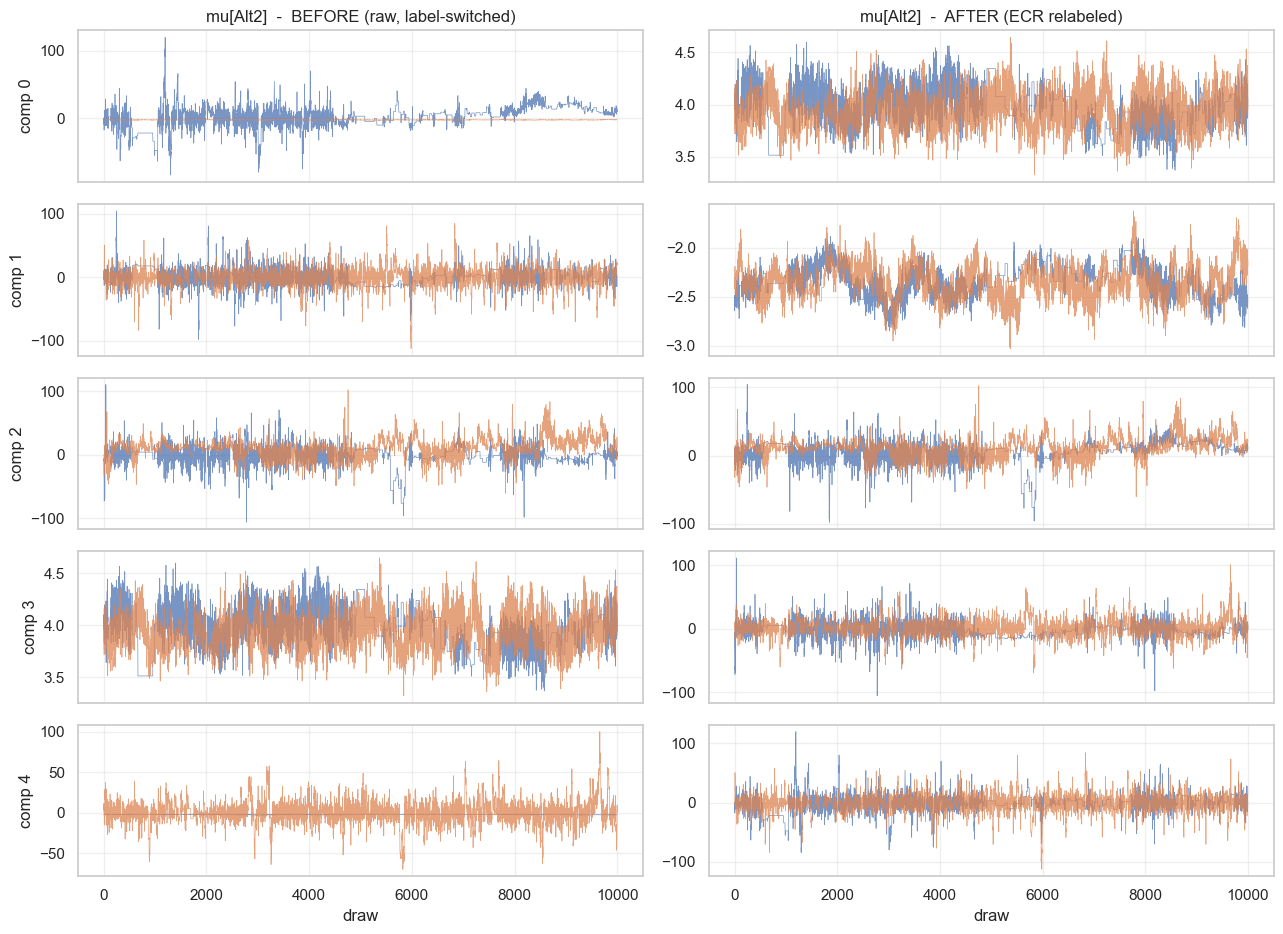

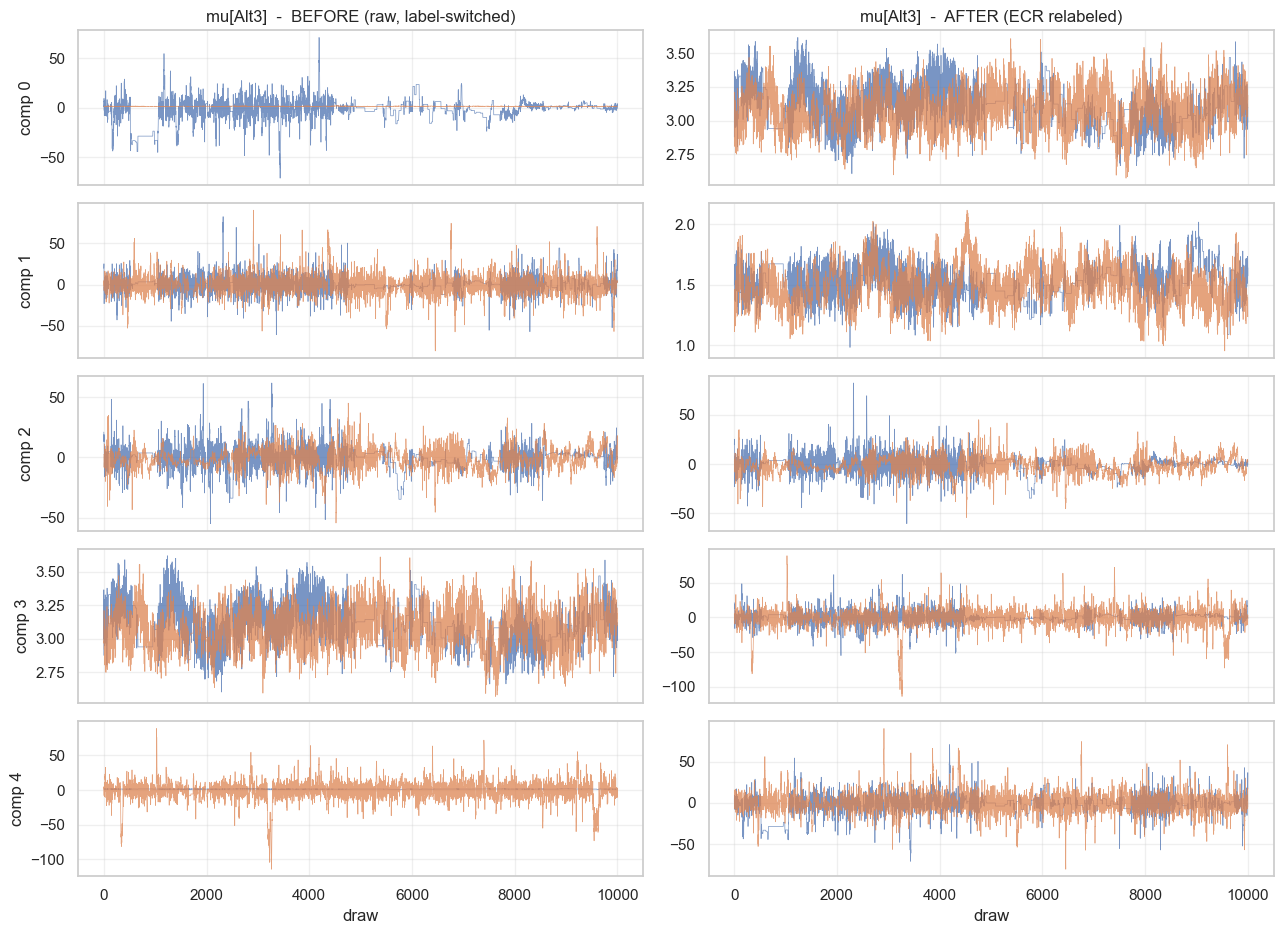

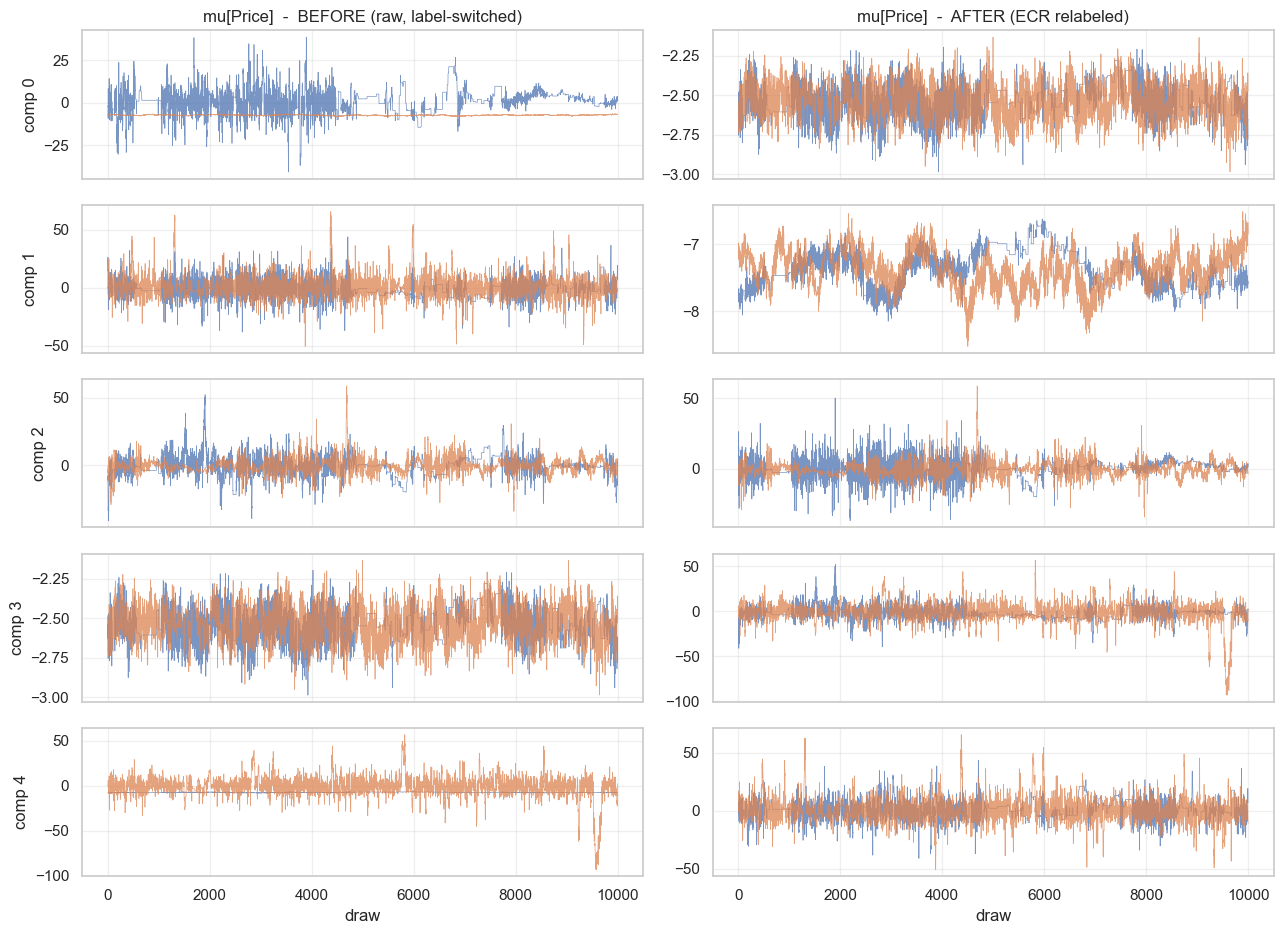

In [7]:
# ── Cell 7 : mu_k - Full Before / After (ALL components, ALL parameters) ──────────
mu_before = np.asarray(posterior_samples["mu_k"])   # (C,S,K,P)
mu_after  = np.asarray(relabeled["mu_k"])
# One trace grid per parameter; each shows every K component before vs after.
for p in range(P):
    ls.plot_before_after_traces(mu_before[:, :, :, p], mu_after[:, :, :, p], K_MODEL,
                                title=f"mu[{param_names[p]}]")

In [8]:
# ── Cell 8 : Cross-Chain Agreement, Recovery & Caveats ──────────
from scipy.optimize import linear_sum_assignment

live = report["live_slots"]   # the K_TRUE heaviest (live) slots

# Per-chain mean of mu[0] for ALL slots: if chains disagree slot-by-slot even
# AFTER relabeling, that is genuine multimodality, not a permutation artifact.
def _per_chain_table(samples):
    pcm = analysis.per_chain_mu_means(samples)
    return pd.DataFrame({ch: v[:, 0] for ch, v in pcm.items()},
                        index=[f"slot {k}" for k in range(K_MODEL)])
print("Per-chain mean of mu[0] per slot - BEFORE:")
display(_per_chain_table(posterior_samples).round(3))
print("AFTER (should agree slot-by-slot if switching was the only problem):")
display(_per_chain_table(relabeled).round(3))

ok = ls.invariance_guard(posterior_samples, relabeled)
print(f"\nInvariance guard (E[u] identical before/after): {ok}")
print("  (no-corruption check only: it passes for ANY consistent permutation, so")
print("   it does NOT by itself certify the relabeling is correct.)\n")

if t_mu is not None:
    rel_mu_mean   = np.asarray(relabeled["mu_k"]).reshape(-1, K_MODEL, P).mean(0)[live]
    rel_pvec_mean = np.asarray(relabeled["pvec"]).reshape(-1, K_MODEL).mean(0)[live]
    cost = ((rel_mu_mean[:, None, :] - t_mu[None, :, :]) ** 2).sum(-1)
    ri, ci = linear_sum_assignment(cost)
    rows = []
    for r, c in zip(ri, ci):
        rows.append({
            "live_slot":   int(live[r]),
            "matched_true": int(c),
            "pvec_post":   round(float(rel_pvec_mean[r]), 3),
            "pvec_true":   round(float(t_pvec[c]), 3) if t_pvec is not None else None,
            "mu_L2_err":   round(float(np.sqrt(((rel_mu_mean[r] - t_mu[c]) ** 2).sum())), 3),
        })
    print("Relabeled live-slot recovery vs ground truth (Hungarian-matched to truth):")
    display(pd.DataFrame(rows))

print("\nCAVEATS (per project methodology):")
print(" - Component-level recovery is ILLUSTRATIVE only; the load-bearing inference")
print("   is on the label-invariant functionals (marginal density, mixture moments).")
print(" - ECR aligns permutations WITHIN a mode; it cannot merge different partition")
print("   modes. If the invariant sorted-pvec R-hat (Cell 4) is high, the weight")
print("   posterior is multimodal - not a label artifact - and these per-component")
print("   summaries remain illustrative, not a recovery.")
print(" - Empty components (K_MODEL > K_TRUE) are unidentified and excluded above.")

# Persist the relabeled draws additively (never touches posterior_raw.pkl).
with open(RESULTS_DIR / "relabeled_posterior.pkl", "wb") as f:
    pickle.dump({k: np.asarray(v) for k, v in relabeled.items()}, f)
print(f"\nSaved relabeled draws -> {(RESULTS_DIR / 'relabeled_posterior.pkl')}")

Per-chain mean of mu[0] per slot - BEFORE:


,chain_0,chain_1
slot 0,-1.359,3.314
slot 1,0.141,2.171
slot 2,1.552,-4.535
slot 3,1.217,1.200
slot 4,3.307,-1.035


AFTER (should agree slot-by-slot if switching was the only problem):


,chain_0,chain_1
slot 0,1.217,1.200
slot 1,3.307,3.314
slot 2,-0.685,-4.908
slot 3,1.525,-1.412
slot 4,-0.506,2.920



Invariance guard (E[u] identical before/after): True
  (no-corruption check only: it passes for ANY consistent permutation, so
   it does NOT by itself certify the relabeling is correct.)

Relabeled live-slot recovery vs ground truth (Hungarian-matched to truth):


,live_slot,matched_true,pvec_post,pvec_true,mu_L2_err
0,0,0,0.510,0.5,0.207
1,1,1,0.477,0.5,0.152



CAVEATS (per project methodology):
 - Component-level recovery is ILLUSTRATIVE only; the load-bearing inference
   is on the label-invariant functionals (marginal density, mixture moments).
 - ECR aligns permutations WITHIN a mode; it cannot merge different partition
   modes. If the invariant sorted-pvec R-hat (Cell 4) is high, the weight
   posterior is multimodal - not a label artifact - and these per-component
   summaries remain illustrative, not a recovery.
 - Empty components (K_MODEL > K_TRUE) are unidentified and excluded above.



Saved relabeled draws -> C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\2_chains\2_comp\HMC\2comp_equal_K5_seed42\results\relabeled_posterior.pkl
